In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy.stats import mannwhitneyu, wilcoxon
import seaborn as sns
import statsmodels.api as sm

C:\Users\gpe9038\AppData\Local\Temp\ipykernel_3500\3480450186.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [760]:
common_config = {
    'dbname': 'db',
    'user': 'codespace',
    'host': 'localhost',
    'project': 'kfc-kiosk-3',
    'location': 'US',
    'query_id': 'bquxjob_159f1b6a_18cedf71333',
    'kiosk_path': '/workspaces/codespaces-blank/bquxjob_567f0b61_18cf4ee3d07.csv',
    'cc_path': '/workspaces/codespaces-blank/cc.xlsx',
    'kassa_path': '/workspaces/codespaces-blank/kassa.xlsx',
    'name': 'ab_test_2',
    'start_date': '2023-12-16',
    'data_collect_start_date': '2023-01-08',
    'data_collect_end_date': '2024-01-08',
    'lower_bound': 0,
    'upper_bound': 1
}

configurations = [
    {
        'slice_type': 'event_date, restraunt_id',
        'aggregator': 'action_order_success',
        'MDE': 0.75 , # %
        'alpha': 0.05,
        'beta': 0.1
    },
]
config = configurations[0]

df = pd.read_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\test_data\data_1.csv')
clusters = pd.read_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\clustered_results.csv')
clusters = clusters.rename(columns={'Fact ID': 'restraunt_id', 'Combined_Cluster': 'strat', 'action_order_success': 'TRX', 'Group': 'group'})[['restraunt_id', 'TRX', 'strat']]

#clusters.restraunt_id = clusters[clusters.restraunt_id.isin(sort)].restraunt_id
#clusters = clusters.dropna()

data = df.merge(clusters, on='restraunt_id')
data['event_date'] = data['event_date'].apply(lambda x: datetime.strptime(str(x), "%Y%m%d").strftime("%Y-%m-%d"))
grouped_size = clusters.groupby('strat').size().to_frame(name='strat_size')
clusters = pd.merge(clusters, grouped_size, on='strat')

control_group, test_group = np.random.choice(
    data.restraunt_id.unique(), (2, int(data.restraunt_id.nunique()/2)), replace=False
)
print(len(control_group), len(test_group))
mu_control = 10000
std = 400
sample_size_test = int(data[data['restraunt_id'].isin(test_group)][config['aggregator']].count())
sample_size_control = int(data[data['restraunt_id'].isin(control_group)][config['aggregator']].count())
sample_size = int(data[config['aggregator']].count())
print(sample_size_test+sample_size_control)
data.loc[data['restraunt_id'].isin(test_group) & (data.event_date < common_config['start_date']), config['aggregator']] = pd.Series(np.random.normal(mu_control, std, sample_size)).astype(np.int64)
data.loc[data['restraunt_id'].isin(control_group) & (data.event_date < common_config['start_date']), config['aggregator']] = pd.Series(np.random.normal(mu_control, std, sample_size)).astype(np.int64)
data.loc[data['restraunt_id'].isin(test_group) & (data.event_date > common_config['start_date']), config['aggregator']] = pd.Series(np.random.normal(mu_control+2000, std, sample_size)).astype(np.int64)
data.loc[data['restraunt_id'].isin(control_group) & (data.event_date > common_config['start_date']), config['aggregator']] = pd.Series(np.random.normal(mu_control, std, sample_size)).astype(np.int64)

data.loc[data['restraunt_id'].isin(test_group) & (data.event_date < common_config['start_date']), 'group'] = 'Test'
data.loc[data['restraunt_id'].isin(control_group) & (data.event_date < common_config['start_date']), 'group'] = 'Control'
data.loc[data['restraunt_id'].isin(test_group) & (data.event_date > common_config['start_date']), 'group'] = 'Test'
data.loc[data['restraunt_id'].isin(control_group) & (data.event_date > common_config['start_date']), 'group'] = 'Control'

print(data[config['aggregator']].isnull().sum(), data[config['aggregator']].isnull().count())

t_alpha = stats.norm.ppf(1 - config['alpha'] / 2, loc=0, scale=1)
t_beta = stats.norm.ppf(1 - config['beta'], loc=0, scale=1)

effect = config['MDE']/100 * data[data.event_date < common_config['start_date']][config['aggregator']].mean()
sample_size = int((t_alpha + t_beta) ** 2 * data[data.event_date < common_config['start_date']][config['aggregator']].var() / (effect ** 2))
print(config['MDE'], '% - ожидаемый эффект')
print(effect, ' - ожидаемый эффект')
print(sample_size, 'размер выборки')
print(sample_size / (len(control_group) + len(test_group)), ' - количество дней теста')

pred_test_duration = 10
print(pred_test_duration, ' - предположительное количество дней теста')
sample_size = pred_test_duration * (len(control_group) + len(test_group))
effect = np.sqrt(int((t_alpha + t_beta) ** 2 * data[data.event_date < common_config['start_date']][config['aggregator']].var() / (sample_size)))
print(effect*100/data[data.event_date < common_config['start_date']][config['aggregator']].mean(), '% - теоретический минимальный эффект')
print(effect, ' - теоретический ожидаемый эффект')
print(sample_size, 'теоретический размер выборки')

16 16
1822
0 1822
0.75 % - ожидаемый эффект
75.07545774647888  - ожидаемый эффект
303 размер выборки
9.46875  - количество дней теста
10  - предположительное количество дней теста
0.7298818417846209 % - теоретический минимальный эффект
73.06161783043132  - теоретический ожидаемый эффект
320 теоретический размер выборки


In [723]:
print(data.event_date.min(), 'начало')
print(data.event_date.max(), 'конец')

2023-11-06 начало
2024-01-08 конец


In [734]:
np.sort(data.event_date.unique())

array(['2023-11-06', '2023-11-07', '2023-11-08', '2023-11-09',
       '2023-11-10', '2023-11-11', '2023-11-12', '2023-11-13',
       '2023-11-14', '2023-11-15', '2023-11-16', '2023-11-17',
       '2023-11-18', '2023-11-19', '2023-11-20', '2023-11-21',
       '2023-11-22', '2023-11-23', '2023-11-24', '2023-11-25',
       '2023-11-26', '2023-11-27', '2023-11-28', '2023-11-29',
       '2023-11-30', '2023-12-01', '2023-12-02', '2023-12-03',
       '2023-12-04', '2023-12-05', '2023-12-06', '2023-12-07',
       '2023-12-08', '2023-12-09', '2023-12-10', '2023-12-11',
       '2023-12-12', '2023-12-13', '2023-12-14', '2023-12-15',
       '2023-12-16', '2023-12-17', '2023-12-18', '2023-12-19',
       '2023-12-20', '2023-12-21', '2023-12-22', '2023-12-23',
       '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-27',
       '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-06',
       '2024-01-07', '2024-01-08'], dtype=object)

In [412]:
#data[config['aggregator']] = np.log(data[data[config['aggregator']] > 0][config['aggregator']])

In [318]:
def calc_strat_mean(df: pd.DataFrame, weights: pd.Series, config) -> float:
    """Считает стратифицированное среднее.

    df - датафрейм с целевой метрикой и данными для стратификации
    weights - маппинг {название страты: вес страты в популяции}
    """
    strat_mean = df.groupby('strat')[config['aggregator']].mean()
    return (strat_mean * weights).sum()


def calc_strat_var(df: pd.DataFrame, weights: pd.Series, config) -> float:
    """Считает стратифицированную дисперсию.
    df - датафрейм с целевой метрикой и данными для стратификации
    weights - маппинг {название страты: вес страты в популяции}
    """
    strat_var = df.groupby('strat')[config['aggregator']].var()
    #print(strat_var)
    return (strat_var * weights**2).sum()


def ttest_strat(a: pd.DataFrame, b: pd.DataFrame, weights: pd.Series, config) -> float:
    """Возвращает pvalue теста Стьюдента для стратифицированного среднего.

    a, b - данные пользователей контрольной и экспериментальной групп
    weights - маппинг {название страты: вес страты в популяции}
    """
    a_strat_mean = calc_strat_mean(a, weights, config)
    b_strat_mean = calc_strat_mean(b, weights, config)
    a_strat_var = calc_strat_var(a, weights, config)
    b_strat_var = calc_strat_var(b, weights, config)
    delta = b_strat_mean - a_strat_mean
    std = (a_strat_var / len(a) + b_strat_var / len(b)) ** 0.5
    t = delta / std
    pvalue = 2 * (1 - stats.norm.cdf(np.abs(t)))
    #print(a.count(), b.count())

    #sample size
    strat_mean = calc_strat_mean(pd.concat([a, b]), weights, config)
    strat_var = calc_strat_var(pd.concat([a, b]), weights, config)

    effect = config['MDE']/100 * strat_mean

    t_alpha = stats.norm.ppf(1 - config['alpha'] / 2, loc=0, scale=1)
    t_beta = stats.norm.ppf(1 - config['beta'], loc=0, scale=1)
    sample_size = int((t_alpha + t_beta) ** 2 * strat_var / (effect ** 2))

    return pvalue, sample_size, strat_var, delta

def calculate_weights(df):
  weights = {}
  for strat in df.strat.unique():
    add = {
        strat: (df[df.strat == strat].restraunt_id.nunique() / df.restraunt_id.nunique())
    }
    weights.update(add)

  return weights

def get_random_data(df, config, replace):
    """Генерирует данные случайным семплированием.
    effect - размер эффекта
    """
    control_group, test_group = np.random.choice(
      df.restraunt_id.unique(), (2, df.restraunt_id.nunique()//2), replace=replace
    )

    df.loc[df['restraunt_id'].isin(test_group), 'group'] = 'Test'
    df.loc[df['restraunt_id'].isin(control_group), 'group'] = 'Control'

    control = df[(df.group == 'Test') \
              & (df.event_date < common_config['start_date'])]

    test = df[(df.group == 'Control')
              & (df.event_date < common_config['start_date'])]

    pilot = test.copy()
    effect = config['MDE'] / 100 * df[config['aggregator']].mean()

    pilot_copy = pilot.copy()
    pilot_copy[config['aggregator']] = pilot_copy[config['aggregator']] + effect
    pilot = pilot_copy

    return control, test, pilot, test_group, control_group

def get_stratified_data(data, config, replace):
    """Генерирует данные стратифицированным семплированием.
    effect - размер эффекта
    """
    df = data.copy()
    test_group_full = []
    control_group_full = []
    for strat in df.strat.unique():
      control_group, test_group = np.random.choice(
        df[df.strat == strat].restraunt_id.unique(), (2, df[df.strat == strat].restraunt_id.nunique()//2), replace=replace
      )

      df.loc[df['restraunt_id'].isin(test_group), 'group'] = 'Test'
      df.loc[df['restraunt_id'].isin(control_group), 'group'] = 'Control'
      
      test_group_full = [*test_group_full, *test_group]
      control_group_full = [*control_group_full, *control_group]

    control = df[(df.group == 'Test') \
              & (df.event_date < common_config['start_date'])]

    test = df[(df.group == 'Control')
              & (df.event_date < common_config['start_date'])]

    pilot = test.copy()
    effect = config['MDE'] / 100 * df[config['aggregator']].mean()

    pilot_copy = pilot.copy()
    pilot_copy[config['aggregator']] = pilot_copy[config['aggregator']] + effect
    pilot = pilot_copy

    
    return control, test, pilot, np.array(test_group_full), np.array(control_group_full)

In [753]:
first_type_errors = []
second_type_errors = []
pvalues = []
sample_size_mean = []
strat_var_mean = []
deltas = []
data['strat'] = 0
d = data.copy()
weights = pd.Series(calculate_weights(d))
print(weights)
for _ in tqdm(range(2000)):
    control_aa, test_aa, test_ab, _, _ = get_random_data(d, config, True)

    pvalue_aa, sample_size, strat_var, delta = ttest_strat(control_aa, test_aa, weights, config)
    first_type_errors.append(pvalue_aa < config['alpha'])
    pvalue_ab, _, _, _ = ttest_strat(control_aa, test_ab, weights, config)

    second_type_errors.append(pvalue_ab >= config['alpha'])
    pvalues.append(pvalue_aa)
    sample_size_mean.append(sample_size)
    strat_var_mean.append(strat_var)
    deltas.append(delta)


part_first_type_errors = np.mean(first_type_errors)
part_second_type_errors = np.mean(second_type_errors)
part_sample_size = np.mean(sample_size_mean)
part_strat_var = np.mean(strat_var_mean)

effect = config['MDE']/100 * d[d.event_date < common_config['start_date']][config['aggregator']].mean()

t_alpha = stats.norm.ppf(1 - config['alpha'] / 2, loc=0, scale=1)
t_beta = stats.norm.ppf(1 - config['beta'], loc=0, scale=1)
sample_size = int((t_alpha + t_beta) ** 2 * d[d.event_date < common_config['start_date']][config['aggregator']].var() / (effect ** 2))
    
print('\n')
print(f'MDE = {config["MDE"]}')
print(f'part_first_type_errors = {part_first_type_errors:0.3f}')
print(f'part_second_type_errors = {part_second_type_errors:0.3f}')
print(f'variation = {d[d.event_date < common_config['start_date']][config['aggregator']].var():0.3f}')
print(f'strat variation = {part_strat_var:0.3f}')
print(f'sample_size = {sample_size:0.3f}')
print(f'strat sample_size = {part_sample_size:0.3f}')
print(f'test duration = {sample_size//data.restraunt_id.nunique():0.3f}')
print(f'strat test duration = {part_sample_size/data.restraunt_id.nunique():0.3f}')



0    1.0
dtype: float64


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:39<00:00, 50.47it/s]



MDE = 0.75
part_first_type_errors = 0.062
part_second_type_errors = 0.133
variation = 171675.930
strat variation = 171673.198
sample_size = 321.000
strat sample_size = 320.995
test duration = 10.000
strat test duration = 10.031


In [754]:
results = {}

for i in tqdm(range(2000)):
    control_aa, test_aa, test_ab, test_group, control_group = get_random_data(d, config, False)

    pvalue_aa, sample_size, strat_var, delta = ttest_strat(control_aa, test_aa, weights, config)
    pvalue_ab, _, _, _ = ttest_strat(control_aa, test_ab, weights, config)
    add = {
        i: (test_group, control_group, pvalue_aa, pvalue_ab, sample_size)
    }
    results.update(add)
    
    
    

100%|██████████| 2000/2000 [00:39<00:00, 50.80it/s]


In [756]:
results[0][3]

0.010853961744284879

In [434]:
results

{0: (array([74221145, 74021973, 74221048, 74021977, 74021806, 74021483,
         74020541, 74220598, 74021481, 74321843, 74021620, 74021029,
         74220971, 74021801, 74020757, 74221444], dtype=int64),
  array([74021396, 74020616, 74220643, 74020582, 74021111, 74321793,
         74220858, 74021836, 74021762, 74020647, 74020810, 74019904,
         74021513, 74021157, 74021880, 74020661], dtype=int64),
  0.9717629210441998,
  0.005925146074014842,
  335),
 1: (array([74020616, 74220971, 74321843, 74221145, 74021762, 74021806,
         74020541, 74021396, 74220858, 74021801, 74021029, 74021513,
         74020810, 74021880, 74020582, 74321793], dtype=int64),
  array([74020661, 74221444, 74021157, 74220643, 74021620, 74220598,
         74019904, 74021973, 74020757, 74020647, 74021481, 74021483,
         74021977, 74021836, 74021111, 74221048], dtype=int64),
  0.5004301481440305,
  0.0006969272302193019,
  335),
 2: (array([74220858, 74021396, 74021836, 74019904, 74021513, 74020757,
     

In [755]:
max_aa = 0
min_ab = 1
sample_size = 12345
for i in range(1000):
    if (results[i][2] > max_aa): #& (results[i][3] < min_ab):
        max_aa = results[i][2]
        min_ab = results[i][3]
        sample_size = results[i][4]
        best_test_group = results[i][0]
        best_control_group = results[i][1]

print(f"MDE = {config['MDE']}")
print(best_test_group)
print(best_control_group)
print(max_aa, 'aa_test')
print(min_ab, 'ab_effect')
print(sample_size, 'sample_size')
print(f'test duration = {sample_size//clusters.restraunt_id.nunique():0.3f}')

data.loc[data['restraunt_id'].isin(best_test_group), 'group'] = 'Test'
data.loc[data['restraunt_id'].isin(best_control_group), 'group'] = 'Control'

MDE = 0.75
[74021620 74020661 74221145 74021513 74020582 74021111 74021483 74221444
 74321793 74220643 74321843 74021157 74021029 74019904 74021806 74020541]
[74020616 74220858 74020757 74021481 74220971 74021762 74220598 74021977
 74021880 74021396 74021801 74021836 74020810 74221048 74020647 74021973]
0.9998622881526797 aa_test
0.0010694112696960634 ab_effect
321 sample_size
test duration = 10.000


In [757]:
clusters.loc[clusters['restraunt_id'].isin(best_test_group), 'group'] = 'Test'
clusters.loc[clusters['restraunt_id'].isin(best_control_group), 'group'] = 'Control'
splitted_data = clusters[['restraunt_id', 'strat', 'TRX','group']].drop_duplicates().dropna().sort_values(['strat', 'group'])
splitted_data.strat = 0
print(len(best_control_group), len(best_test_group), splitted_data.restraunt_id.count())
splitted_data.head(30)


16 16 32


,restraunt_id,strat,TRX,group
4,74021396,0,12444,Control
6,74020810,0,12305,Control
5,74019904,0,12444,Test
7,74221145,0,12559,Test
8,74021836,0,13018,Control
9,74021762,0,13124,Control
10,74021029,0,13138,Test
11,74021483,0,13088,Test
12,74321793,0,13249,Test
13,74020661,0,13225,Test


In [422]:
np.max([6, 6666666])

6666666

In [758]:
data

,event_date,restraunt_id,session_count,tap_auth_count,tap_email_count,tap_sms_count,action_order_start,action_order_success,action_auth_order_success,revenue,avg_product_count,conversion_rate_total,conversion_rate_auth,TRX,strat,group
0,2023-12-18,74020582,194,0,0,0,194,11999,3,78324.0,3.043478,0.829897,0.015464,11853,0,Test
1,2023-12-18,74020661,223,0,0,0,223,10271,2,80192.0,2.925714,0.784753,0.008969,13225,0,Test
2,2023-12-18,74021762,267,0,0,0,267,10028,6,82278.0,2.870647,0.752809,0.022472,13124,0,Control
3,2023-12-18,74321843,81,0,0,0,81,11044,1,33133.0,3.355932,0.728395,0.012346,4725,0,Test
4,2023-12-19,74020647,132,0,0,0,132,12188,1,42900.0,2.692982,0.863636,0.007576,9342,0,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,2023-11-11,74021157,151,0,0,0,151,9736,1,40267.0,3.459459,0.490066,0.006623,4737,0,Test
1818,2023-11-11,74021513,61,0,0,0,61,10733,0,26198.0,4.479167,0.786885,0.000000,4713,0,Test
1819,2023-11-18,74020616,313,0,0,0,313,9825,3,156387.0,3.792453,0.846645,0.009585,12008,0,Control
1820,2023-11-18,74021762,362,0,0,0,362,10015,2,138344.0,3.507299,0.756906,0.005525,13124,0,Control


In [759]:
control_before = data[(data.group == 'Test') \
            & (data.event_date < common_config['start_date'])]

test_before = data[(data.group == 'Control')
            & (data.event_date < common_config['start_date'])]

control_after = data[(data.group == 'Test') \
            & (data.event_date > common_config['start_date'])]

test_after = data[(data.group == 'Control')
            & (data.event_date > common_config['start_date'])]\
                
print('до')
print(control_before.action_order_success.mean())
print(test_before.action_order_success.mean())
print(control_before.action_order_success.var())
print(test_before.action_order_success.var())
print('после')
print(control_after.action_order_success.mean())
print(test_after.action_order_success.mean())
print(control_after.action_order_success.var())
print(test_after.action_order_success.var())

до
9994.280564263323
9994.2765625
154164.15820878628
189401.55563135757
после
11011.94140625
11030.84375
1298003.3181219362
1156580.744117647


In [750]:
a = data.copy()
a.event_date = a.event_date.str.replace('-', '')
a['strat'] = 0
a.to_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\test_data\data_1_testing.csv')
splitted_data.to_csv(r'\\mosfil02.int.tgr.net\UsersFolders$\gpe9038\Desktop\ROSTICS-LAB\project\static\test_data\groups.csv')

<Axes: xlabel='action_order_success', ylabel='Count'>

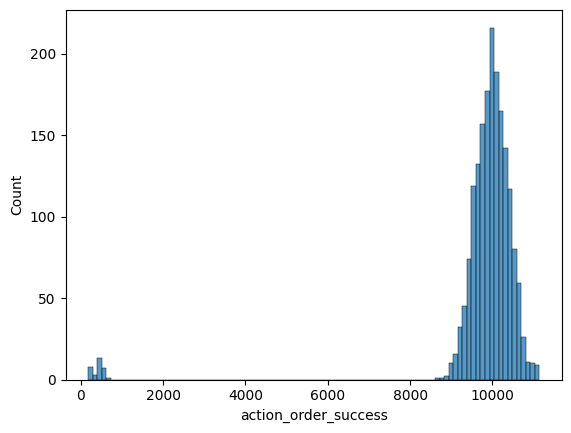

In [749]:
sns.histplot(data[config['aggregator']], bins=100)

<Axes: ylabel='Count'>

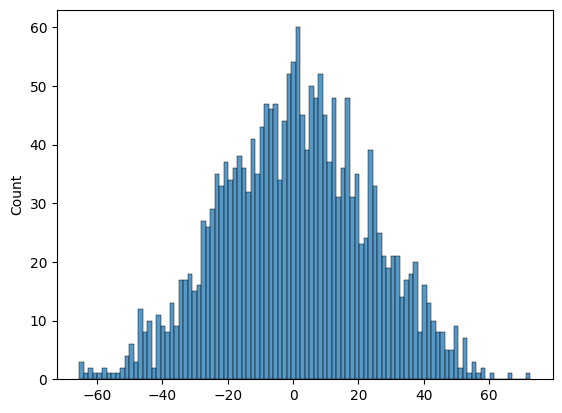

In [742]:
sns.histplot(deltas, bins=100)

<Axes: ylabel='Count'>

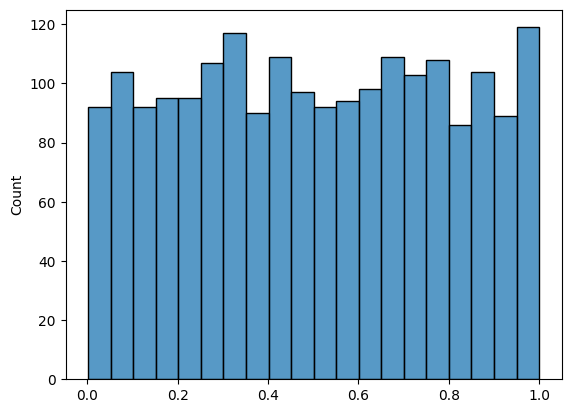

In [743]:
sns.histplot(pvalues, bins=20)

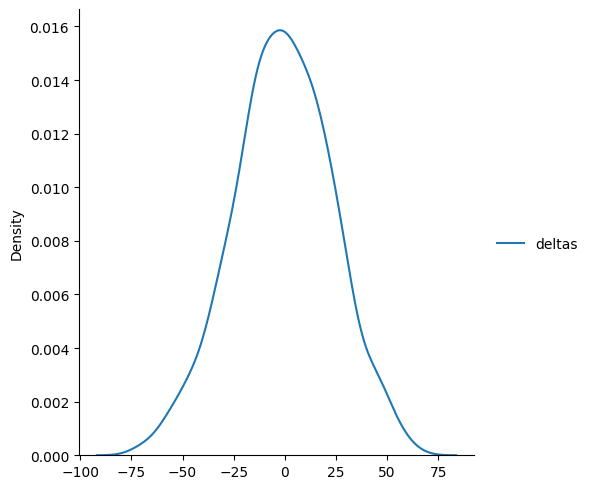

In [400]:
sns.displot(
    {'deltas': deltas},
    kind='kde'
)

<Axes: >

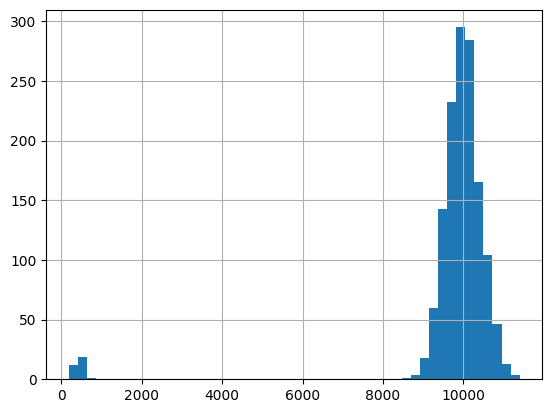

In [710]:
data[data[config['aggregator']] > 0][config['aggregator']].hist(bins=50)

<Axes: >

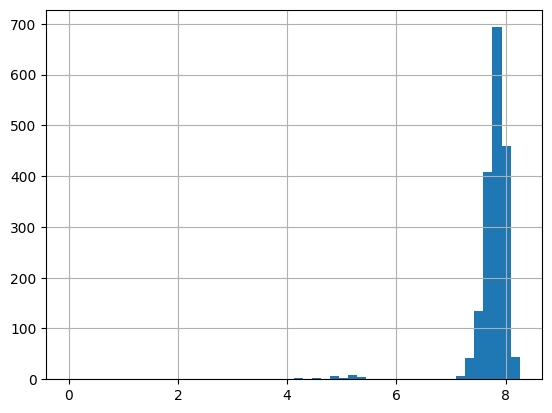

In [403]:
np.log(data[data[config['aggregator']] > 0][config['aggregator']]).hist(bins=50)

In [404]:
data[config['aggregator']]

0       3198
1       2522
2       2906
3       2512
4       2492
        ... 
1817    3041
1818    2358
1819    2707
1820    2332
1821    2665
Name: action_order_success, Length: 1822, dtype: int64

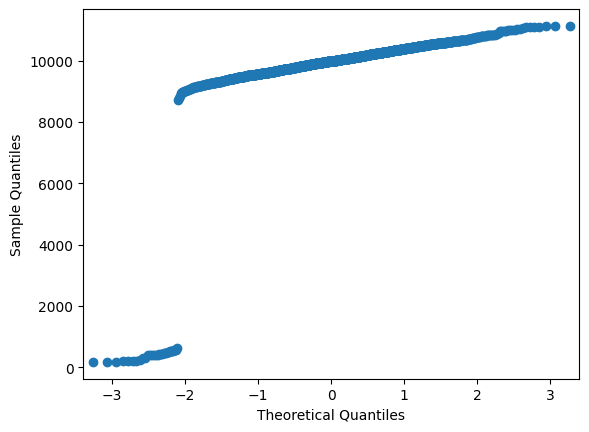

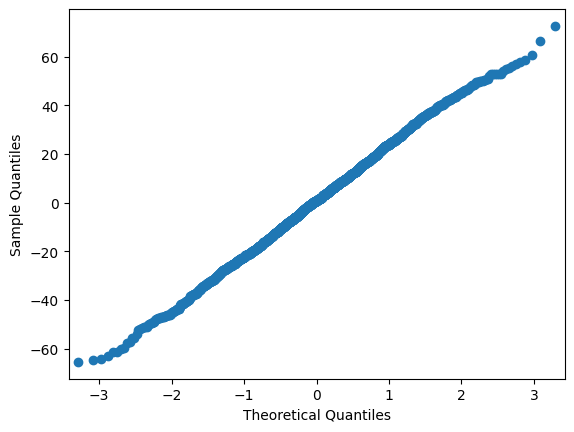

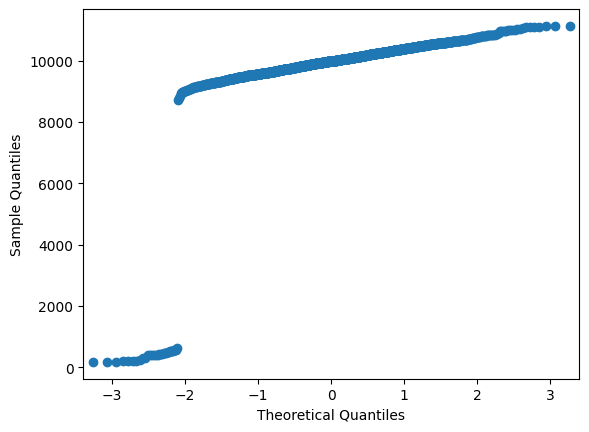

In [747]:
sm.qqplot(np.array(deltas))
sm.qqplot(data[data[config['aggregator']] > 0][config['aggregator']])
#sm.qqplot(np.log(data[data[config['aggregator']] > 0][config['aggregator']]))

In [714]:
import scipy.stats as stats

#Levene's test centered at the median
stats.levene(control_after[config['aggregator']].dropna(), test_after[config['aggregator']].dropna(), center='mean')


LeveneResult(statistic=0.30859164999769706, pvalue=0.5799394069947919)

In [720]:
t = (control_after.action_order_success.mean() - test_after.action_order_success.mean()) / \
  np.sqrt(control_after.action_order_success.var()/control_after.action_order_success.count() + test_after.action_order_success.var()/test_after.action_order_success.count())
t

0.5436056930539845

In [721]:
pvalue = 2 * (1 - stats.norm.cdf(np.abs(t)))
pvalue

0.5867128413085971